# Avaliação do Modelo — Sistema Inteligente de Limite de Crédito
**Projeto Final · FIA/LABDATA — Dia 3 (CRISP-DM: Evaluation)**

Avalia o modelo de Probabilidade de Default (PD) treinado por `3_train.py` e demonstra a **política de limite** (`credit_policy.py`): risco → limite → prazo.

> Rode `3_train.py` antes (gera o modelo, as métricas e as predições de teste).
> Execute célula a célula no VS Code.

## 0. Dependências (rode se faltar alguma biblioteca)

In [1]:
%pip install scikit-learn pandas numpy matplotlib joblib pyyaml

  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached narwhals-2.23.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.23.0-py3-none-any.whl (458 kB)
Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl (20.4 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn]0m 4/5 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


## 1. Setup — carregar config, modelo, métricas e predições

In [12]:
import json, yaml, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import credit_policy   # modulo da politica (mesma pasta)

plt.rcParams["figure.figsize"]=(7,4); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3
AZUL,VERM,TEAL="#0F2C4C","#C0392B","#1C7293"

CFG=yaml.safe_load(open("config.yaml",encoding="utf-8"))
ROOT=next((p for p in [Path(".."),Path(".")] if (p/CFG["paths"]["metrics"]).exists()), Path(".."))
metrics=json.load(open(ROOT/CFG["paths"]["metrics"],encoding="utf-8"))
model=joblib.load(ROOT/CFG["paths"]["model"])
pred=pd.read_csv(ROOT/CFG["paths"]["test_predictions"])
TGT=CFG["columns"]["target"]; INC=CFG["columns"]["income"]
print("Melhor modelo:", metrics["best_model"])
pred.head()

Melhor modelo: HistGradientBoosting


,SK_ID_CURR,TARGET,PD,AMT_INCOME_TOTAL
0,396899,0,0.443642,157500.0
1,322041,0,0.373538,90000.0
2,220127,0,0.795473,148500.0
3,251531,0,0.322479,188100.0
4,345558,0,0.520224,180000.0


In [13]:
pred.tail()

,SK_ID_CURR,TARGET,PD,AMT_INCOME_TOTAL
61498,118908,0,0.409432,162000.0
61499,441326,0,0.389522,180000.0
61500,371501,0,0.302182,360000.0
61501,272785,1,0.596921,337500.0
61502,411571,0,0.512114,225000.0


## 2. Métricas técnicas (AUC, KS, Gini)

In [14]:
lr, hgb = metrics["logistic_regression"], metrics["hist_gradient_boosting"]
tab=pd.DataFrame({"Logistic Regression":lr,"HistGradientBoosting":hgb}).T[["auc","ks","gini"]]
print(tab.round(4))
print("\nLimiar otimo (KS):", metrics["threshold_otimo"])
print("Interpretacao: AUC>0.5 separa; KS = maior distancia entre bons e maus.")

                         auc      ks    gini
Logistic Regression   0.7452  0.3658  0.4903
HistGradientBoosting  0.7622  0.3900  0.5244

Limiar otimo (KS): 0.4811
Interpretacao: AUC>0.5 separa; KS = maior distancia entre bons e maus.


## 3. Curva ROC e estatística KS

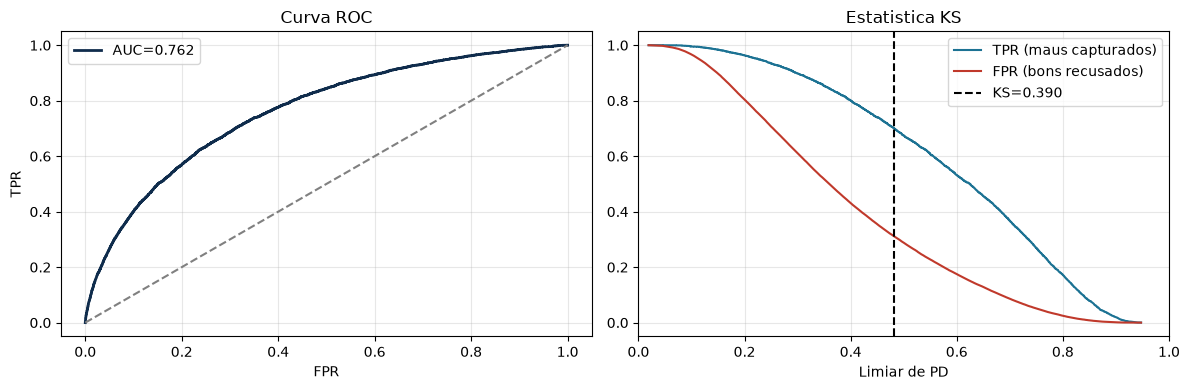

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
y=pred[TGT].values; p=pred["PD"].values
fpr,tpr,thr=roc_curve(y,p); auc=roc_auc_score(y,p)
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(fpr,tpr,color=AZUL,lw=2,label=f"AUC={auc:.3f}"); ax[0].plot([0,1],[0,1],"--",color="gray")
ax[0].set_title("Curva ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ks_idx=np.argmax(tpr-fpr)
ax[1].plot(thr,tpr,color=TEAL,label="TPR (maus capturados)"); ax[1].plot(thr,fpr,color=VERM,label="FPR (bons recusados)")
ax[1].axvline(thr[ks_idx],ls="--",color="black",label=f"KS={tpr[ks_idx]-fpr[ks_idx]:.3f}")
ax[1].set_xlim(0,1); ax[1].set_title("Estatistica KS"); ax[1].set_xlabel("Limiar de PD"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. Matriz de confusão no limiar ótimo

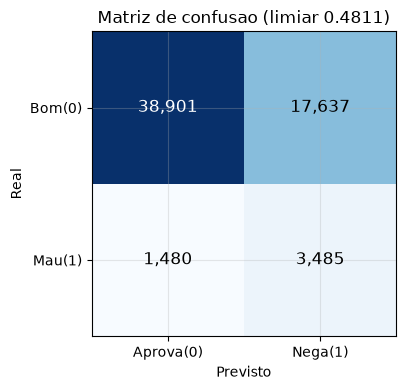

              precision    recall  f1-score   support

  Adimplente       0.96      0.69      0.80     56538
Inadimplente       0.16      0.70      0.27      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.69      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
thr_opt=metrics["threshold_otimo"]
yhat=(p>=thr_opt).astype(int)
cm=confusion_matrix(y,yhat)
fig,ax=plt.subplots(figsize=(4.5,4))
im=ax.imshow(cm,cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j,i,f"{cm[i,j]:,}",ha="center",va="center",
                color="white" if cm[i,j]>cm.max()/2 else "black",fontsize=12)
ax.set_xticks([0,1]); ax.set_xticklabels(["Aprova(0)","Nega(1)"]); ax.set_yticks([0,1]); ax.set_yticklabels(["Bom(0)","Mau(1)"])
ax.set_xlabel("Previsto"); ax.set_ylabel("Real"); ax.set_title(f"Matriz de confusao (limiar {thr_opt})")
plt.tight_layout(); plt.show()
print(classification_report(y,yhat,target_names=["Adimplente","Inadimplente"]))

## 5. Distribuição do score (PD) por classe

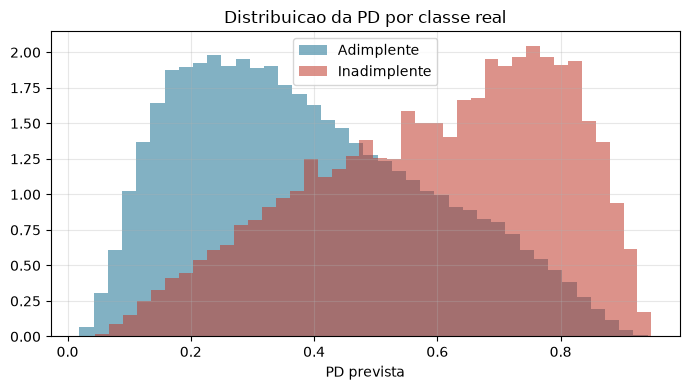

Bom modelo: inadimplentes concentrados a direita (PD alta).


In [17]:
fig,ax=plt.subplots(figsize=(7,4))
for t,cor,lab in [(0,TEAL,"Adimplente"),(1,VERM,"Inadimplente")]:
    ax.hist(p[y==t],bins=40,density=True,alpha=0.55,color=cor,label=lab)
ax.set_title("Distribuicao da PD por classe real"); ax.set_xlabel("PD prevista"); ax.legend()
plt.tight_layout(); plt.show()
print("Bom modelo: inadimplentes concentrados a direita (PD alta).")

## 6. Variáveis mais importantes (permutation importance)

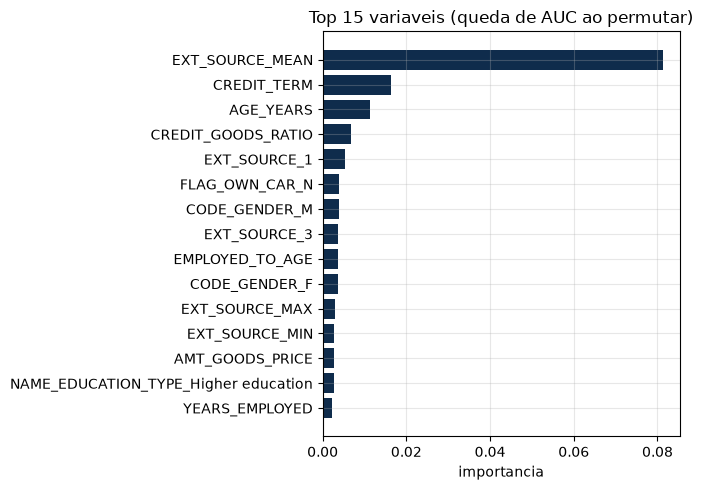

In [18]:
top=pd.DataFrame(metrics["top_features"],columns=["feature","importancia"]).iloc[::-1]
fig,ax=plt.subplots(figsize=(7,5))
ax.barh(top["feature"],top["importancia"],color=AZUL)
ax.set_title("Top 15 variaveis (queda de AUC ao permutar)"); ax.set_xlabel("importancia")
plt.tight_layout(); plt.show()

## 7. Política de limite — do risco à oferta
Aplica `credit_policy.recomendar(PD, renda)` a cada cliente do teste.

In [19]:
cfg_pol=credit_policy.load_policy_cfg("config.yaml")
recs=[credit_policy.recomendar(pd_i,renda_i,cfg_pol) for pd_i,renda_i in zip(pred["PD"],pred[INC])]
rec=pd.DataFrame(recs)
pred2=pred.join(rec[["faixa","decisao","limite_recomendado","prazo_meses"]])

# distribuicao por faixa de risco
dist=pred2.groupby("faixa").agg(clientes=("PD","size"),pd_medio=("PD","mean"),
      limite_medio=("limite_recomendado","mean"),inadimplencia_real=(TGT,"mean")).round(3)
print(dist)

       clientes  pd_medio  limite_medio  inadimplencia_real
faixa                                                      
A           169     0.040    146878.338               0.006
B          5702     0.113     80363.675               0.014
C         16654     0.226     31222.334               0.026
D         26447     0.435      6314.077               0.069
E         12531     0.718         0.000               0.211


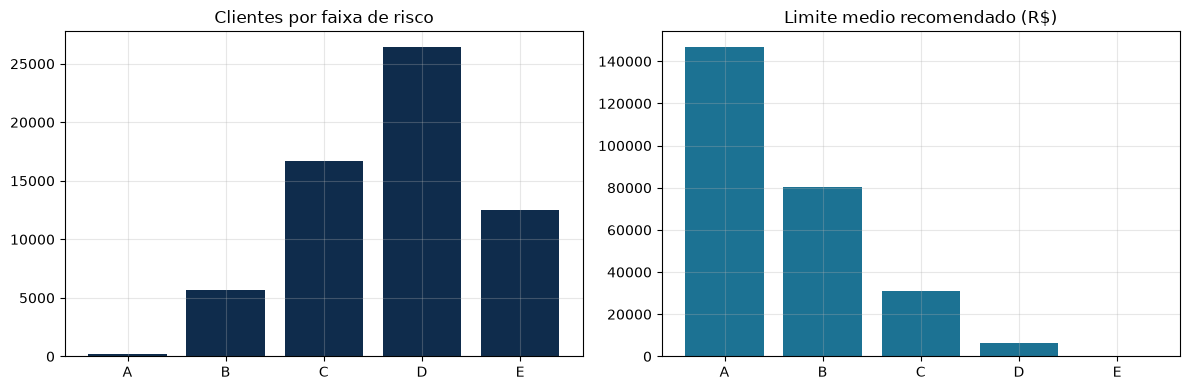

In [24]:
# grafico: clientes e limite medio por faixa
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].bar(dist.index,dist["clientes"],color=AZUL); ax[0].set_title("Clientes por faixa de risco")
ax[1].bar(dist.index,dist["limite_medio"],color=TEAL); ax[1].set_title("Limite medio recomendado (R$)")
plt.tight_layout(); plt.show()

## 8. Exemplos de clientes (como no pitch)

In [23]:
ex=pred2.sort_values("PD").iloc[[0, len(pred2)//2, -1]][[INC,"PD","faixa","decisao","limite_recomendado","prazo_meses"]]
ex.columns=["Renda anual","PD","Faixa","Decisao","Limite R$","Prazo (m)"]
print(ex.to_string(index=False, col_space=18, justify="center"))

    Renda anual            PD               Faixa             Decisao            Limite R$          Prazo (m)    
     270000.0           0.019157              A               Aprovar           187468.79              48        
     180000.0           0.376026              D               Aprovar             6923.99              12        
     135000.0           0.947339              E               Recusar                0.00               0        


## 9. Impacto de negócio — perda esperada da carteira
Perda esperada = Σ (PD × limite recomendado × LGD), apenas sobre clientes aprovados.

In [26]:
lgd=cfg_pol["lgd"]
aprov=pred2[pred2["decisao"]=="Aprovar"].copy()
aprov["perda_esperada"]=aprov["PD"]*aprov["limite_recomendado"]*lgd
exposicao=aprov["limite_recomendado"].sum()
perda=aprov["perda_esperada"].sum()
print(f"Clientes aprovados: {len(aprov):,} de {len(pred2):,} ({len(aprov)/len(pred2):.1%})")
print(f"Exposicao total recomendada: R$ {exposicao:,.0f}")
print(f"Perda esperada (LGD={lgd:.0%}): R$ {perda:,.0f}  ({perda/exposicao:.2%} da exposicao)")

Clientes aprovados: 48,972 de 61,503 (79.6%)
Exposicao total recomendada: R$ 1,170,021,265
Perda esperada (LGD=45%): R$ 108,853,638  (9.30% da exposicao)


## 10. Conclusão (preencher com os números obtidos)

- O modelo de PD separa bem bons e maus pagadores (ver AUC/KS acima).
- A política traduz o PD em limite e prazo coerentes com o risco e a renda.
- A perda esperada da carteira recomendada fica controlada (ver seção 9).
- **Confiança/governança**: monitorar AUC/KS no tempo, PSI das variáveis e revisar as faixas periodicamente.